In [137]:
import pandas as pd
import numpy as np
from sklearn .datasets import make_classification
import matplotlib.pyplot as plt

In [139]:
X,y = make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [141]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['targets']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,targets
0,-0.866425,-1.198666,2.684473,0.567371,1.040634,1
1,0.810984,1.175498,-0.153507,-2.094443,2.893412,1
2,-0.881095,0.433815,1.276081,-0.871931,1.236762,1
3,2.062761,-0.104523,-0.832515,-3.245462,1.365280,0
4,1.302024,1.372812,2.886406,-0.032223,0.725497,0


In [143]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [145]:
import random

In [147]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['targets'] = df['targets']
  return new_df
     

In [149]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)
     

## row sampling

In [152]:
df1=sample_rows(df,0.2)
print(df1.shape)
print(df1)
df2=sample_rows(df,0.2)
print(df2.shape)
print(df2)
df3=sample_rows(df,0.2)
print(df3.shape)
print(df3)

(20, 6)
        col1      col2      col3      col4      col5  targets
20 -0.217021  0.070989  0.540780 -0.735737  2.030742        1
48  0.549737  2.192138  2.380903  0.104113  0.335008        0
66 -0.097819  0.462503  1.902991 -1.685798  2.399122        1
71  1.588480  0.347754 -0.847521 -2.457690  1.286106        0
98 -1.158926 -1.826529  2.694832 -0.941391  1.404903        1
7  -1.419110 -1.057189  3.985830  0.813508  0.852173        1
92 -2.237095  0.264375  2.172899  0.823071 -0.073925        1
60 -0.790139  2.281280  0.692300 -0.169021  1.325904        0
76 -1.669857 -2.154820 -0.003811 -1.597404  0.041520        1
74  2.848156 -0.523556 -1.244475 -3.791606  2.512101        0
60 -0.790139  2.281280  0.692300 -0.169021  1.325904        0
48  0.549737  2.192138  2.380903  0.104113  0.335008        0
91 -1.225543  0.183174  4.487093  0.654812 -0.302483        1
29 -0.923000 -1.018285  0.562621 -0.905217  0.580493        1
41  1.454677  1.861384  4.347700  0.099868  3.096389        1


In [154]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [156]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [158]:
from sklearn.tree import plot_tree



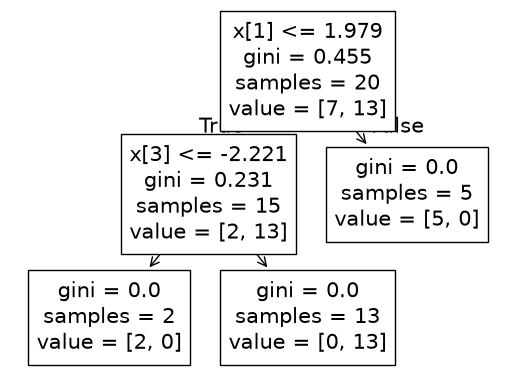

In [160]:
plot_tree(clf1)
plt.show()

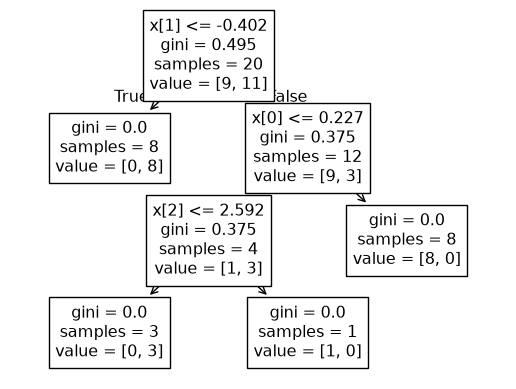

In [162]:
plot_tree(clf2)
plt.show()

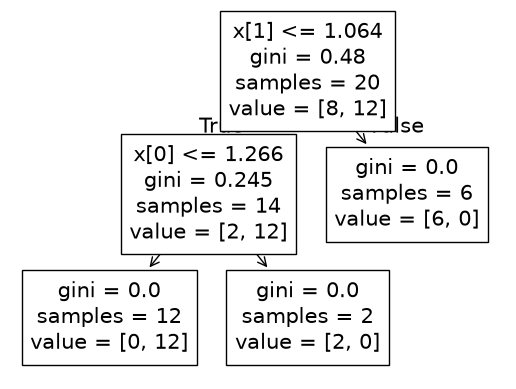

In [164]:
plot_tree(clf3)
plt.show()

In [166]:
clf1.predict(np.array([1.761035, -1.487051, -2.484221 , 0.111703,  0.929564  ]).reshape(1,5))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [171]:

clf2.predict(np.array([1.761035, -1.487051,-2.484221,  0.111703,  0.929564  ]).reshape(1,5))


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [173]:
clf3.predict(np.array([1.761035, -1.487051 ,-2.484221 , 0.111703 , 0.929564  ]).reshape(1,5))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

##  columns sampling

In [176]:
df1=sample_features(df,0.5)
print(df1.shape)
print(df1)
df2=sample_features(df,0.5)
print(df2.shape)
print(df2)
df3=sample_features(df,0.5)
print(df3.shape)
print(df3)

(100, 3)
        col5      col3  targets
0   1.040634  2.684473        1
1   2.893412 -0.153507        1
2   1.236762  1.276081        1
3   1.365280 -0.832515        0
4   0.725497  2.886406        0
..       ...       ...      ...
95  0.324488  1.614106        1
96 -0.510840  0.029144        0
97 -0.151072  0.036430        0
98  1.404903  2.694832        1
99  1.806242  0.363778        0

[100 rows x 3 columns]
(100, 3)
        col4      col3  targets
0   0.567371  2.684473        1
1  -2.094443 -0.153507        1
2  -0.871931  1.276081        1
3  -3.245462 -0.832515        0
4  -0.032223  2.886406        0
..       ...       ...      ...
95 -1.101372  1.614106        1
96 -1.221527  0.029144        0
97 -1.313214  0.036430        0
98 -0.941391  2.694832        1
99 -2.281914  0.363778        0

[100 rows x 3 columns]
(100, 3)
        col1      col4  targets
0  -0.866425  0.567371        1
1   0.810984 -2.094443        1
2  -0.881095 -0.871931        1
3   2.062761 -3.245462       

In [178]:
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [180]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

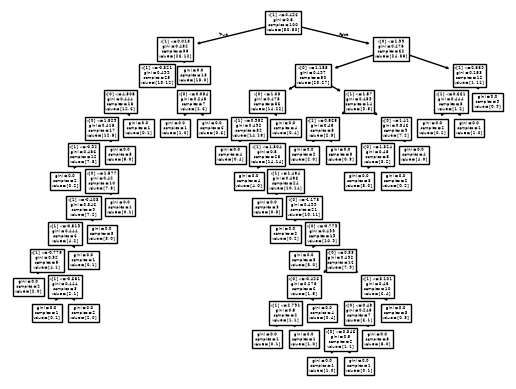

In [182]:
plot_tree(clf1)
plt.show()

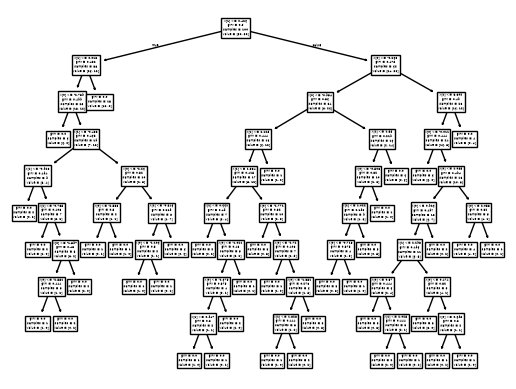

In [183]:
plot_tree(clf2)
plt.show()

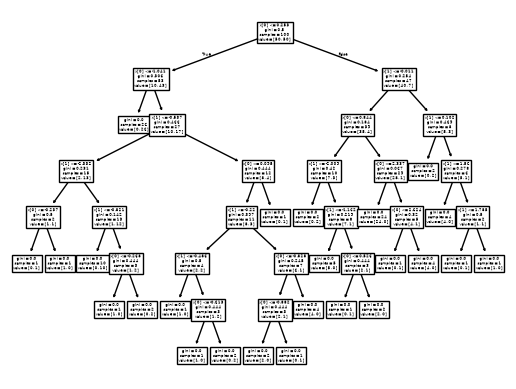

In [185]:
plot_tree(clf3)
plt.show()

In [186]:
clf1.predict(np.array([-1.003179  , 1.010731  ]).reshape(1,2))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [188]:
clf2.predict(np.array([-1.003179  , 1.010731  ]).reshape(1,2))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [191]:
clf3.predict(np.array([-1.003179  , 1.010731  ]).reshape(1,2))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

## combined sampling

In [195]:
df1 = combined_sampling(df,0.5,0.5)
print(df1.columns)
print(df1.shape)   
print(df1)
     
df2 = combined_sampling(df,0.5,0.5)
print(df2.columns)
print(df2.shape)   
print(df2)
     
df3 = combined_sampling(df,0.5,0.5)
print(df3.columns)
print(df3.shape)   
print(df2)
     

Index(['col2', 'col3', 'targets'], dtype='str')
(50, 3)
        col2      col3  targets
74 -0.523556 -1.244475        0
7  -1.057189  3.985830        1
87 -1.411552 -0.382656        1
23 -0.117645 -0.610547        0
52 -0.585834  2.164471        0
72 -2.341640  1.813238        1
48  2.192138  2.380903        0
81  0.338061  0.401679        0
14 -1.820954 -0.024116        1
29 -1.018285  0.562621        1
63  1.475710  0.273378        0
89  3.077690  3.010876        0
75  0.754501  1.494188        1
29 -1.018285  0.562621        1
52 -0.585834  2.164471        0
75  0.754501  1.494188        1
81  0.338061  0.401679        0
9   0.469570  1.044360        1
42  1.231081  0.237938        0
61 -0.320971  1.734087        1
9   0.469570  1.044360        1
85 -0.667884  0.962781        1
61 -0.320971  1.734087        1
80  1.050153  2.012505        0
61 -0.320971  1.734087        1
25 -1.635032  1.043291        1
71  0.347754 -0.847521        0
76 -2.154820 -0.003811        1
98 -1.826529  2.

In [196]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
     

In [197]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

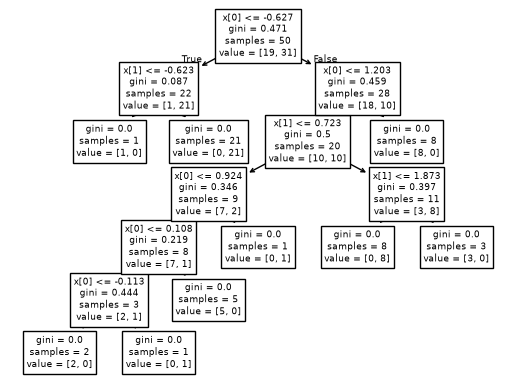

In [199]:
plot_tree(clf1)
plt.show()

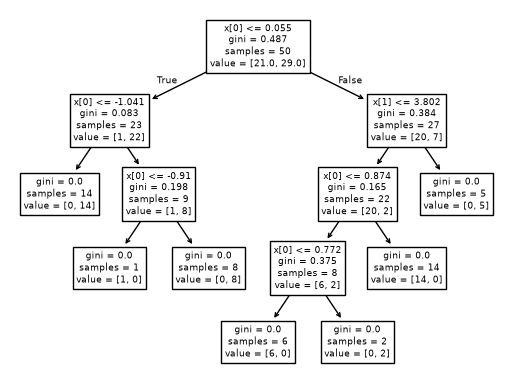

In [202]:
plot_tree(clf2)
plt.show()

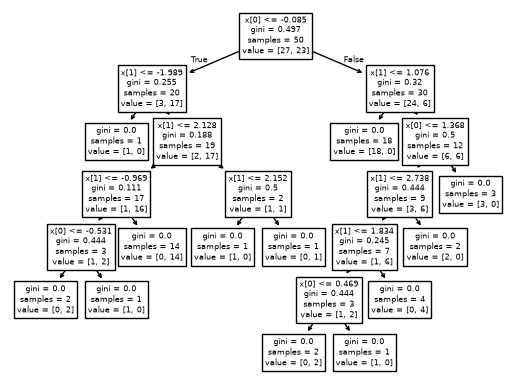

In [203]:
plot_tree(clf3)
plt.show()

In [205]:
clf1.predict(np.array([-2.339055, -2.440443]).reshape(1,2))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [207]:
clf2.predict(np.array([-2.339055, -2.440443]).reshape(1,2))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [209]:
clf3.predict(np.array([-2.339055, -2.440443]).reshape(1,2))

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])